# 0) Imports + chargement des données

In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
print(" Current working directory (cwd):", cwd)

# On affiche le contenu du cwd pour vérifier
print("\n Contenu du dossier courant :")
for p in sorted(cwd.iterdir()):
    print(" -", p.name)

# On vérifie quelques chemins possibles
candidates = [
    cwd / "data" / "raw" / "ottawa_places_from_osm.csv",
    cwd.parent / "data" / "raw" / "ottawa_places_from_osm.csv",
]
print("\n Vérification chemins candidats :")
for c in candidates:
    print(" if c.exists() else ", c)

 Current working directory (cwd): c:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\notebooks

 Contenu du dossier courant :
 - CityTaste_DataPipeline_EDA.ipynb
 - pipeline_pretraitement.ipynb

 Vérification chemins candidats :
 if c.exists() else  c:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\notebooks\data\raw\ottawa_places_from_osm.csv
 if c.exists() else  c:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\raw\ottawa_places_from_osm.csv


In [2]:
import pandas as pd

def find_project_root(start: Path, rel_target: Path, max_up=6) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if (cur / rel_target).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Impossible de trouver {rel_target} en remontant depuis {start}")

REL = Path("data/raw/ottawa_places_from_osm.csv")
PROJECT_ROOT = find_project_root(Path.cwd(), REL)
DATA_PATH = PROJECT_ROOT / REL

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)

PROJECT_ROOT: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste
DATA_PATH: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\raw\ottawa_places_from_osm.csv
Shape: (1104, 21)


# 0B — Visualisation (aperçu + types)

In [3]:
display(df_raw.head(10))

,osm_type,osm_id,name,place_type,amenity,tourism,cuisine,lat,lon,addr_housenumber,...,addr_city,addr_postcode,address,phone,website,opening_hours,wheelchair,brand,source,tags_json
0,relation,14526702,Les Suites Hotel,hotel,NaN,hotel,NaN,45.426134,-75.688731,130,...,Ottawa,K1N 9M9,130 Besserer Street,+1 613 232 2000,https://www.les-suites.com/,NaN,yes,NaN,City of Ottawa,"{""@id"": ""relation/14526702"", ""addr:city"": ""Ott..."
1,way,31813259,Embassy Hotel and Suites,hotel,NaN,hotel,NaN,45.419679,-75.688818,25,...,Ottawa,K2P 1J2,25 Cartier Street,NaN,NaN,NaN,NaN,NaN,NaN,"{""@id"": ""way/31813259"", ""addr:housenumber"": ""2..."
2,way,31813278,The Business Inn & Suites,hotel,NaN,hotel,NaN,45.416980,-75.689237,180,...,Ottawa,NaN,180 MacLaren Street,+1-613-232-1121,https://www.thebusinessinn.com/,NaN,NaN,NaN,City of Ottawa,"{""@id"": ""way/31813278"", ""addr:housenumber"": ""1..."
3,way,46016942,Ottawa Jail Hostel,hostel,NaN,hostel,NaN,45.425111,-75.688451,75,...,Ottawa,K1N 7B9,75 Nicholas Street,NaN,https://saintlo.ca/en/hostels/ottawa-jail/,NaN,NaN,NaN,NaN,"{""@id"": ""way/46016942"", ""addr:housenumber"": ""7..."
4,way,55411730,Sonder Rideau Apartments Downtown,hotel,NaN,hotel,NaN,45.420741,-75.694605,161,...,Ottawa,K1P 5J2,161 Laurier Avenue West,NaN,NaN,NaN,NaN,NaN,NaN,"{""@id"": ""way/55411730"", ""addr:housename"": ""Res..."
5,way,56065304,Hampton Inn by Hilton Ottawa,hotel,NaN,hotel,NaN,45.421379,-75.657039,100,...,Ottawa,K1K 4S3,100 Coventry Road,+1 613-741-2300,https://www.hilton.com/en/hotels/yowcnhx-hampt...,NaN,NaN,Hampton,City of Ottawa,"{""@id"": ""way/56065304"", ""addr:housenumber"": ""1..."
6,way,56104394,Perkins,restaurant,restaurant,NaN,american,45.424555,-75.638345,1130,...,Ottawa,NaN,1130 St-Laurent Boulevard,NaN,NaN,24/7,yes,Perkins,City of Ottawa,"{""@id"": ""way/56104394"", ""addr:housenumber"": ""1..."
7,way,66923906,Capital Hill Hotel & Suites,hotel,NaN,hotel,NaN,45.421723,-75.695620,88,...,Ottawa,K1P 5E9,88 Albert Street,NaN,https://www.capitalhill.com/,NaN,NaN,NaN,City of Ottawa,"{""@id"": ""way/66923906"", ""addr:housenumber"": ""8..."
8,way,68587061,St-Hubert,restaurant,restaurant,NaN,chicken;barbecue,45.405019,-75.627083,1754,...,Ottawa,K1G 1A2,1754 St-Laurent Boulevard,NaN,NaN,11:00-22:00; Fr-Sa 11:00-23:00,yes,St-Hubert,City of Ottawa,"{""@id"": ""way/68587061"", ""addr:housenumber"": ""1..."
9,way,68587644,Senpai,restaurant,restaurant,NaN,sushi,45.367954,-75.774275,2280,...,Ottawa,NaN,2280 Carling Avenue,NaN,NaN,NaN,NaN,NaN,CanVec 6.0 - NRCan,"{""@id"": ""way/68587644"", ""addr:housenumber"": ""2..."


# 1) EDA rapide (manquants + distributions)

In [4]:
missing = (df_raw.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_tbl = missing.reset_index()
missing_tbl.columns = ["col", "missing_%"]

display(missing_tbl)

# Distributions clés
place_counts = df_raw["place_type"].value_counts(dropna=False)
amenity_counts = df_raw["amenity"].value_counts(dropna=False)
tourism_counts = df_raw["tourism"].value_counts(dropna=False)

display(place_counts.to_frame("count"))
display(amenity_counts.to_frame("count").head(15))
display(tourism_counts.to_frame("count").head(15))

# Top cuisines (restaurants)
if "cuisine" in df_raw.columns:
    display(df_raw["cuisine"].value_counts(dropna=False).head(20).to_frame("count"))

,col,missing_%
0,tourism,91.39
1,wheelchair,88.86
2,brand,84.24
3,opening_hours,77.54
4,addr_postcode,77.36
5,phone,72.28
6,website,65.31
7,source,62.50
8,cuisine,31.97
9,amenity,8.61


,count
place_type,
restaurant,1009
hotel,66
guest_house,16
motel,10
hostel,3


,count
amenity,
restaurant,1009
NaN,95


,count
tourism,
NaN,1009
hotel,66
guest_house,16
motel,10
hostel,3


,count
cuisine,
NaN,353
indian,71
chinese,62
pizza,60
italian,47
vietnamese,42
sushi,30
thai,28
mexican,26


### Résultats (EDA rapide : manquants & distributions)
- Les **valeurs manquantes** ne sont pas uniformes : certaines colonnes sont souvent vides (ex: contacts, horaires, site web), ce qui est typique des données OSM.
- La distribution de `place_type` montre un **déséquilibre** (souvent beaucoup plus de restaurants que d’hébergements), ce qui influencera l’évaluation et les recommandations.
- Les variables `amenity/tourism` confirment la variété des lieux.
- Pour les restaurants, `cuisine` présente une **forte diversité** (beaucoup de catégories), avec plusieurs valeurs rares.
Conclusion : on garde les lignes et on traite les manquants + on prévoit une stratégie robuste pour les catégories rares/nouvelles.

### 1B — Visualisation (bar manquants + bar place_type)

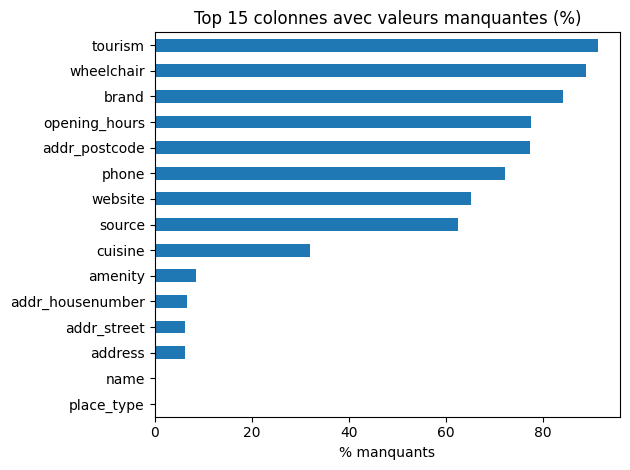

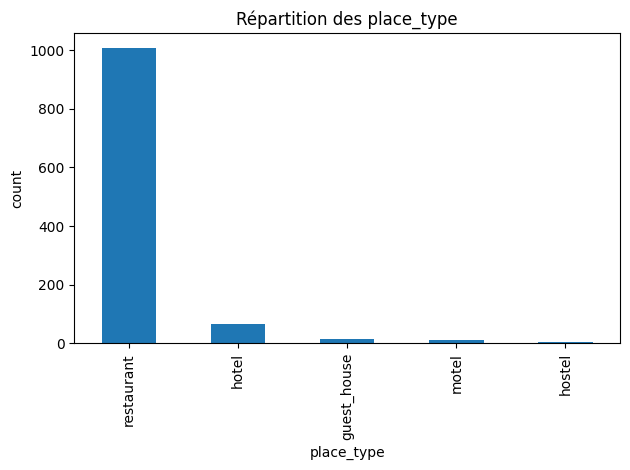

In [5]:
# Bar plot des manquants
plt.figure()
missing.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 colonnes avec valeurs manquantes (%)")
plt.xlabel("% manquants")
plt.tight_layout()
plt.show()

# Bar plot place_type
plt.figure()
place_counts.plot(kind="bar")
plt.title("Répartition des place_type")
plt.xlabel("place_type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Résultats (visualisation manquants)
Le graphique des manquants montre clairement les colonnes les plus “incomplètes”.
- Ces colonnes ne doivent pas forcément être supprimées : elles peuvent être utiles via des stratégies simples (ex: `Unknown`, indicateurs `has_phone`, etc.).
- Les colonnes critiques pour la recommandation (ex: `lat/lon`, `place_type`, éventuellement `cuisine`) doivent rester **fiables**.
 Décision : on évite le `dropna` global et on applique une imputation ciblée selon le type de variable.

### 2) Nettoyage + feature engineering (distance, texte)

In [6]:
df = df_raw.copy()

# 1) Nettoyage minimal : retirer lignes sans lat/lon
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df = df.dropna(subset=["lat", "lon"]).copy()

# 2) Enlever doublons (osm_id unique normalement)
if "osm_id" in df.columns:
    df = df.drop_duplicates(subset=["osm_id"]).copy()

# 3) Remplir manquants (catégoriel -> Unknown, texte -> "", numérique -> médiane plus tard)
cat_cols_fill = ["place_type", "amenity", "tourism", "cuisine", "wheelchair", "brand", "addr_city", "addr_postcode"]
for c in cat_cols_fill:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown").astype(str)

text_cols = ["name", "address", "addr_street", "phone", "website", "opening_hours", "tags_json"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna("").astype(str)

# 4) Construire une adresse "propre"
df["address_clean"] = (
    df.get("addr_housenumber", "").astype(str).fillna("") + " " +
    df.get("addr_street", "").astype(str).fillna("") + ", " +
    df.get("addr_city", "Unknown").astype(str).fillna("Unknown") + " " +
    df.get("addr_postcode", "Unknown").astype(str).fillna("Unknown")
).str.replace(r"\s+", " ", regex=True).str.strip()

# 5) Feature distance au centre-ville (Ottawa centre approx)
def haversine_km(lat1, lon1, lat2=45.4215, lon2=-75.6972):
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df["dist_to_center_km"] = haversine_km(df["lat"].values, df["lon"].values)

# 6) Colonne texte (pour TF-IDF)
df["text"] = (
    df["name"] + " " +
    df["place_type"] + " " +
    df.get("cuisine", "Unknown") + " " +
    df["address_clean"] + " " +
    df.get("tags_json", "")
).str.replace(r"\s+", " ", regex=True).str.strip()

# 7) Label proxy pour évaluer (restaurants => cuisine, hébergements => place_type)
df["eval_label"] = np.where(df["place_type"].eq("restaurant"), df.get("cuisine", "Unknown"), df["place_type"])

print("Après nettoyage:", df.shape)

Après nettoyage: (1104, 25)


### 2B — Visualisation (carte scatter + histogram distance + manquants après)

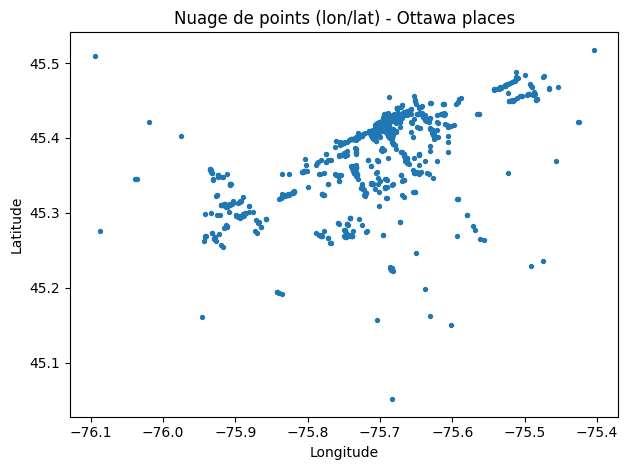

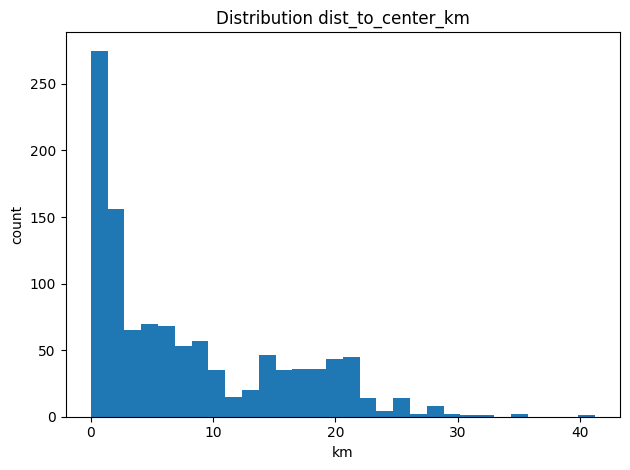

,missing_%
source,62.50
addr_housenumber,6.61
name,0.00
osm_id,0.00
amenity,0.00
tourism,0.00
cuisine,0.00
place_type,0.00
osm_type,0.00
lon,0.00


,osm_id,name,place_type,cuisine,dist_to_center_km,address_clean
0,14526702,Les Suites Hotel,hotel,Unknown,0.838080,"130 Besserer Street, Ottawa K1N 9M9"
1,31813259,Embassy Hotel and Suites,hotel,Unknown,0.684773,"25 Cartier Street, Ottawa K2P 1J2"
2,31813278,The Business Inn & Suites,hotel,Unknown,0.799298,"180 MacLaren Street, Ottawa Unknown"
3,46016942,Ottawa Jail Hostel,hostel,Unknown,0.792124,"75 Nicholas Street, Ottawa K1N 7B9"
4,55411730,Sonder Rideau Apartments Downtown,hotel,Unknown,0.219363,"161 Laurier Avenue West, Ottawa K1P 5J2"
5,56065304,Hampton Inn by Hilton Ottawa,hotel,Unknown,3.134404,"100 Coventry Road, Ottawa K1K 4S3"
6,56104394,Perkins,restaurant,american,4.605865,"1130 St-Laurent Boulevard, Ottawa Unknown"
7,66923906,Capital Hill Hotel & Suites,hotel,Unknown,0.125813,"88 Albert Street, Ottawa K1P 5E9"
8,68587061,St-Hubert,restaurant,chicken;barbecue,5.771821,"1754 St-Laurent Boulevard, Ottawa K1G 1A2"
9,68587644,Senpai,restaurant,sushi,8.465806,"2280 Carling Avenue, Ottawa Unknown"


In [7]:
# Scatter lat/lon (vue rapide)
plt.figure()
plt.scatter(df["lon"], df["lat"], s=8)
plt.title("Nuage de points (lon/lat) - Ottawa places")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# Histogramme distance
plt.figure()
plt.hist(df["dist_to_center_km"], bins=30)
plt.title("Distribution dist_to_center_km")
plt.xlabel("km")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Manquants après nettoyage
missing_after = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_after.head(15).to_frame("missing_%"))
display(df[["osm_id", "name", "place_type", "cuisine", "dist_to_center_km", "address_clean"]].head(10))

### Résultats (qualité après nettoyage)
Après le nettoyage :
- Les colonnes clés sont mieux contrôlées (notamment `lat/lon` et les champs catégoriels remplis avec `Unknown`).
- Les champs texte vides sont normalisés (chaîne vide), ce qui évite des erreurs dans TF-IDF.
- L’aperçu des colonnes (`name`, `place_type`, `cuisine`, `dist_to_center_km`) confirme la cohérence des enregistrements.
 Conclusion : les données sont prêtes pour le split et le pipeline de features.

### 3) Split train/test (sans fuite) 
##### 3A — Split (stratifié par place_type)

In [8]:
from sklearn.model_selection import train_test_split

# Stratifier par place_type pour garder la proportion restaurants/hôtels
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["place_type"]
)

print("Train:", train_df.shape, "Test:", test_df.shape)

Train: (883, 25) Test: (221, 25)


### 3B — Visualisation (répartition train/test)

,train,test
place_type,,
restaurant,807,202
hotel,53,13
guest_house,13,3
motel,8,2
hostel,2,1


<Figure size 640x480 with 0 Axes>

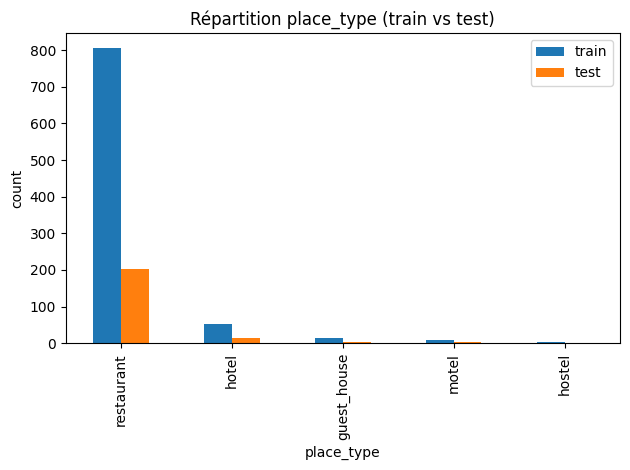

In [9]:
dist_tbl = pd.DataFrame({
    "train": train_df["place_type"].value_counts(),
    "test": test_df["place_type"].value_counts()
}).fillna(0).astype(int)

display(dist_tbl)

plt.figure()
dist_tbl.plot(kind="bar")
plt.title("Répartition place_type (train vs test)")
plt.xlabel("place_type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Résultats (vérification du split)
Le tableau et le graphique montrent que la répartition `place_type` est **semblable** entre train et test.
- Cela valide le choix d’un split **stratifié**.
- Cela réduit le risque d’une évaluation trompeuse due à un test trop déséquilibré.
 Conclusion : on peut évaluer plus proprement la généralisation du pipeline.

### 4) Pipeline de prétraitement (TF-IDF + catégoriel + numérique)
##### Cellule 4A — Définir le preprocess (ColumnTransformer)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer

# Colonnes
text_col = "text"
numeric_cols = ["lat", "lon", "dist_to_center_km"]
cat_cols = ["place_type", "cuisine", "wheelchair", "brand", "addr_city", "addr_postcode"]

# Garder seulement celles qui existent
numeric_cols = [c for c in numeric_cols if c in train_df.columns]
cat_cols = [c for c in cat_cols if c in train_df.columns]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        min_df=2,
        ngram_range=(1, 2),
        max_features=5000
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_col),
        ("num", numeric_pipe, numeric_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

X_train = preprocess.fit_transform(train_df)
X_test = preprocess.transform(test_df)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (883, 3717)
X_test  shape: (221, 3717)


### 4B — Visualisation (infos matrice + densité)

In [11]:
# Densité approximative si sparse
try:
    nnz = X_train.nnz
    total = X_train.shape[0] * X_train.shape[1]
    print("Non-zeros:", nnz, " / ", total, "=> densité ~", nnz/total)
except Exception as e:
    print("Matrice dense ou info nnz indisponible:", e)

# Petit tableau de contrôle
display(train_df[[c for c in ["name","place_type","cuisine","dist_to_center_km","eval_label"] if c in train_df.columns]].head(10))

Non-zeros: 55360  /  3282111 => densité ~ 0.016867193096150618


,name,place_type,cuisine,dist_to_center_km,eval_label
267,Lucky Panda Fine Chinese,restaurant,chinese,18.256268,chinese
849,T'Basil,restaurant,thai,14.243914,thai
15,Comfort Inn Ottawa West - Kanata,hotel,Unknown,19.337860,hotel
133,Spicy Ho Ho,restaurant,regional;chinese,6.033219,regional;chinese
784,A La Istanbul Turkish Cuisine,restaurant,turkish,0.789400,turkish
1041,Raahi Indian Dhaba,restaurant,indian,20.432406,indian
929,Citizen,restaurant,Unknown,0.810044,Unknown
470,My Thai Village,restaurant,thai,20.304014,thai
1038,Pizza Hut,restaurant,pizza,5.300806,pizza
489,JAX,restaurant,american;brunch,1.629116,american;brunch


### Résultats (matrice de features)
La matrice `X_train` est généralement :
- de grande dimension (TF-IDF + one-hot),
- majoritairement **sparse** (beaucoup de zéros), ce qui est normal pour du texte/catégories.
Le tableau de contrôle confirme que les colonnes métier restent cohérentes après préparation.
 Conclusion : la représentation est adaptée à un modèle de similarité (cosine) et à kNN.

### 5) Modèle de recommandation (kNN cosine)
##### Cellule 5A — Fit NearestNeighbors

In [12]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=15)
knn.fit(X_train)
print("kNN entraîné ")

kNN entraîné 


### 5B — Visualisation (exemple de recommandations en tableau)

In [13]:
# Exemple: recommander pour 1 item du test
idx = np.random.randint(0, len(test_df))
query_row = test_df.iloc[idx]

# distances cosine: 0 = identique, donc similarité = 1 - distance
distances, indices = knn.kneighbors(X_test[idx], n_neighbors=10)

recos = train_df.iloc[indices[0]].copy()
recos["cosine_distance"] = distances[0]
recos["similarity"] = 1 - recos["cosine_distance"]

print("QUERY:", query_row.get("name", ""))
display(query_row[[c for c in ["name","place_type","cuisine","address_clean","eval_label"] if c in query_row.index]].to_frame("value"))

display(recos[[c for c in ["name","place_type","cuisine","similarity","eval_label"] if c in recos.columns]].head(10))

QUERY: Luxe Bistro


,value
name,Luxe Bistro
place_type,restaurant
cuisine,steak_house
address_clean,"47 York Street, Ottawa Unknown"
eval_label,steak_house


,name,place_type,cuisine,similarity,eval_label
1023,Harmons Steakhouse,restaurant,steak_house,0.931233,steak_house
841,Madisons,restaurant,steak_house,0.916163,steak_house
1054,Oz Kafe,restaurant,Unknown,0.838935,Unknown
620,Oh So Good,restaurant,cake,0.808708,cake
619,Chickpeas,restaurant,caribbean,0.808305,caribbean
762,Gyubee Japanese Grill,restaurant,japanese,0.805769,japanese
708,Tucker’s Marketplace,restaurant,buffet,0.803222,buffet
903,The Bistro,restaurant,Unknown,0.800756,Unknown
996,The Keg,restaurant,steak_house,0.799465,steak_house
922,Bistro Ristoro,restaurant,mediterranean,0.792900,mediterranean


### Résultats (exemple de recommandations)
Pour une requête (item du test), le modèle renvoie les voisins les plus proches avec une similarité élevée.
- On observe généralement une cohérence sur `place_type` (restaurant avec restaurant) et souvent sur `cuisine` (si disponible).
- La similarité décroît progressivement, ce qui indique un classement logique.
 Conclusion : qualitativement, les recommandations semblent plausibles (contrôle “humain”).

### 6) Évaluation (HitRate@K + MRR@K)
#### Cellule 6A — Calcul des métriques

In [14]:
def evaluate_hits_mrr(knn_model, Xq, train_labels, test_labels, K=10):
    distances, indices = knn_model.kneighbors(Xq, n_neighbors=K)
    hits = []
    rr = []
    for i in range(Xq.shape[0]):
        true_label = test_labels[i]
        neigh_labels = train_labels[indices[i]]
        # Hit@K
        hit = int(np.any(neigh_labels == true_label))
        hits.append(hit)
        # MRR@K
        rank = 0
        for j, lab in enumerate(neigh_labels, start=1):
            if lab == true_label:
                rank = j
                break
        rr.append(1/rank if rank > 0 else 0.0)
    return float(np.mean(hits)), float(np.mean(rr))

train_labels = train_df["eval_label"].values
test_labels = test_df["eval_label"].values

Ks = [1, 3, 5, 10]
rows = []
for K in Ks:
    hit, mrr = evaluate_hits_mrr(knn, X_test, train_labels, test_labels, K=K)
    rows.append({"K": K, "HitRate@K": hit, "MRR@K": mrr})

metrics_df = pd.DataFrame(rows)
display(metrics_df)

,K,HitRate@K,MRR@K
0,1,0.819005,0.819005
1,3,0.864253,0.839367
2,5,0.877828,0.842534
3,10,0.895928,0.844646


### Résultats (métriques)
- **HitRate@K** augmente généralement avec K : plus K est grand, plus on a de chances d’avoir au moins un voisin correct.
- **MRR@K** évalue surtout la qualité du **top du classement** (si les bons résultats arrivent tôt, la MRR est meilleure).
 
 Remarque : l’évaluation repose sur un **label proxy** (`eval_label`). Les scores donnent une indication utile mais ne remplacent pas des interactions utilisateurs réelles.
 Conclusion : le pipeline fournit une performance raisonnable et mesurable pour une recommandation “content-based”.

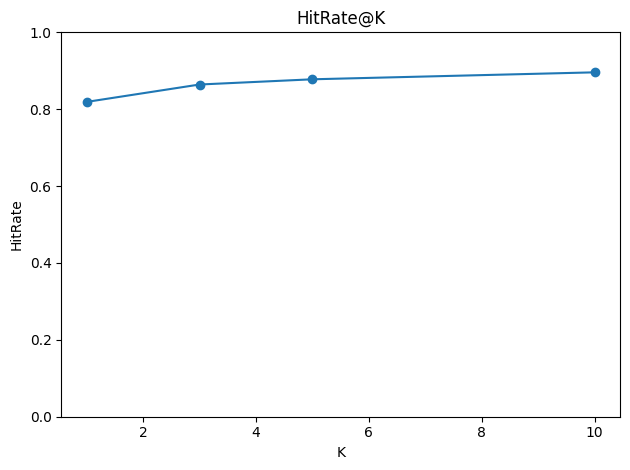

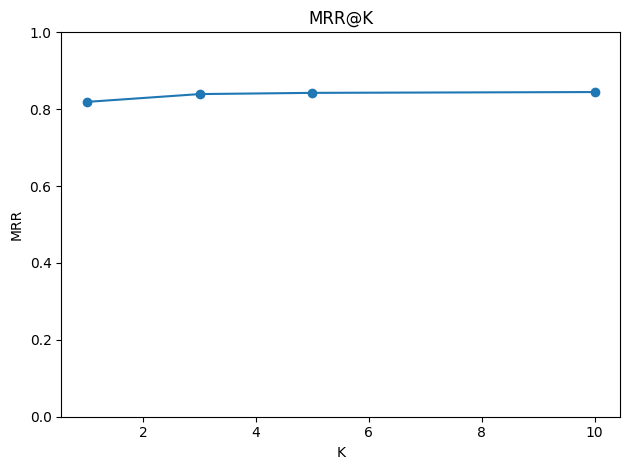

In [15]:
# Visualisation des métriques
plt.figure()
plt.plot(metrics_df["K"], metrics_df["HitRate@K"], marker="o")
plt.title("HitRate@K")
plt.xlabel("K")
plt.ylabel("HitRate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(metrics_df["K"], metrics_df["MRR@K"], marker="o")
plt.title("MRR@K")
plt.xlabel("K")
plt.ylabel("MRR")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Résultats (lecture des courbes)
- La courbe HitRate@K valide l’effet du K : on capture plus facilement un “hit” en élargissant le voisinage.
- La courbe MRR@K permet de juger si les meilleurs voisins sont bien classés en première position (objectif : bons résultats dès le top 1–3).
 Conclusion : ces courbes rendent l’évaluation plus lisible et justifient le choix d’un K (ex: 5 ou 10) pour la démo.

### 7) Sauvegarde (dataset nettoyé + artefacts)
##### Cellule 7A — Sauvegarder

In [16]:
from pathlib import Path
import joblib
import pandas as pd

# Trouver la racine du projet (dossier qui contient /data)
def find_project_root(start: Path, marker_dir: str = "data", max_up: int = 6) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if (cur / marker_dir).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    # fallback : dossier courant
    return start.resolve()

PROJECT_ROOT = find_project_root(Path.cwd(), "data")
OUT_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Sauvegarder dataset nettoyé
clean_path = OUT_DIR / "ottawa_places_cleaned_v2.csv"
df.to_csv(clean_path, index=False)

# 2) Sauvegarder artefacts modèle
joblib.dump(preprocess, OUT_DIR / "preprocess.joblib")
joblib.dump(knn, OUT_DIR / "knn_model.joblib")

# 3) Sauvegarder métriques
metrics_path = OUT_DIR / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(" Saved:")
print(" -", clean_path)
print(" -", metrics_path)

 Saved:
 - C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\ottawa_places_cleaned_v2.csv
 - C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\metrics.csv


### 7B — Visualisation (liste fichiers + aperçu)

In [17]:
# Visualisation / vérification
print("\n Fichiers dans", OUT_DIR)
for f in sorted(OUT_DIR.glob("*")):
    print(" -", f.name)

display(pd.read_csv(metrics_path))
display(pd.read_csv(clean_path).head(5))


 Fichiers dans C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed
 - citytaste_ottawa.db
 - knn_model.joblib
 - metrics.csv
 - ottawa_places_clean.csv
 - ottawa_places_cleaned_v2.csv
 - preprocess.joblib


,K,HitRate@K,MRR@K
0,1,0.819005,0.819005
1,3,0.864253,0.839367
2,5,0.877828,0.842534
3,10,0.895928,0.844646


,osm_type,osm_id,name,place_type,amenity,tourism,cuisine,lat,lon,addr_housenumber,...,website,opening_hours,wheelchair,brand,source,tags_json,address_clean,dist_to_center_km,text,eval_label
0,relation,14526702,Les Suites Hotel,hotel,Unknown,hotel,Unknown,45.426134,-75.688731,130,...,https://www.les-suites.com/,NaN,yes,Unknown,City of Ottawa,"{""@id"": ""relation/14526702"", ""addr:city"": ""Ott...","130 Besserer Street, Ottawa K1N 9M9",0.838080,Les Suites Hotel hotel Unknown 130 Besserer St...,hotel
1,way,31813259,Embassy Hotel and Suites,hotel,Unknown,hotel,Unknown,45.419679,-75.688818,25,...,NaN,NaN,Unknown,Unknown,NaN,"{""@id"": ""way/31813259"", ""addr:housenumber"": ""2...","25 Cartier Street, Ottawa K2P 1J2",0.684773,Embassy Hotel and Suites hotel Unknown 25 Cart...,hotel
2,way,31813278,The Business Inn & Suites,hotel,Unknown,hotel,Unknown,45.416980,-75.689237,180,...,https://www.thebusinessinn.com/,NaN,Unknown,Unknown,City of Ottawa,"{""@id"": ""way/31813278"", ""addr:housenumber"": ""1...","180 MacLaren Street, Ottawa Unknown",0.799298,The Business Inn & Suites hotel Unknown 180 Ma...,hotel
3,way,46016942,Ottawa Jail Hostel,hostel,Unknown,hostel,Unknown,45.425111,-75.688451,75,...,https://saintlo.ca/en/hostels/ottawa-jail/,NaN,Unknown,Unknown,NaN,"{""@id"": ""way/46016942"", ""addr:housenumber"": ""7...","75 Nicholas Street, Ottawa K1N 7B9",0.792124,Ottawa Jail Hostel hostel Unknown 75 Nicholas ...,hostel
4,way,55411730,Sonder Rideau Apartments Downtown,hotel,Unknown,hotel,Unknown,45.420741,-75.694605,161,...,NaN,NaN,Unknown,Unknown,NaN,"{""@id"": ""way/55411730"", ""addr:housename"": ""Res...","161 Laurier Avenue West, Ottawa K1P 5J2",0.219363,Sonder Rideau Apartments Downtown hotel Unknow...,hotel


### Résultats (vérification de sauvegarde)
- Les fichiers attendus sont présents dans `data/processed` : dataset nettoyé, métriques et artefacts du pipeline/modèle.
- La relecture de `metrics.csv` confirme que les résultats sont bien persistés.
- L’aperçu du dataset nettoyé confirme que l’export est lisible et complet.
 Conclusion : le pipeline est **reproductible** (on peut relancer et réutiliser les artefacts pour l’app).

### 1 — Setup MLflow + chemins robustes

In [18]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

def find_project_root(start: Path, marker_dir: str = "data", max_up: int = 6) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if (cur / marker_dir).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

PROJECT_ROOT = find_project_root(Path.cwd(), "data")
OUT_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste
OUT_DIR: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed


### 2 — Fonctions (preprocess + évaluation + run)

In [21]:
import time
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors

def build_preprocess(include_text=True, use_svd=False, max_features=5000, n_components=200,
                     text_col="text", numeric_cols=None, cat_cols=None):
    numeric_cols = numeric_cols or []
    cat_cols = cat_cols or []

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    transformers = []

    if include_text:
        text_steps = [
            ("tfidf", TfidfVectorizer(
                min_df=2,
                ngram_range=(1, 2),
                max_features=max_features
            ))
        ]
        if use_svd:
            text_steps.append(("svd", TruncatedSVD(n_components=n_components, random_state=42)))

        transformers.append(("text", Pipeline(text_steps), text_col))

    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))

    if cat_cols:
        transformers.append(("cat", cat_pipe, cat_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.3
    )

def eval_hits_mrr(knn_model, Xq, train_labels, test_labels, K=10):
    distances, indices = knn_model.kneighbors(Xq, n_neighbors=K)

    hits = []
    rr = []

    for i in range(Xq.shape[0]):
        true_label = test_labels[i]
        neigh_labels = train_labels[indices[i]]

        hit = int(np.any(neigh_labels == true_label))
        hits.append(hit)

        rank = 0
        for j, lab in enumerate(neigh_labels, start=1):
            if lab == true_label:
                rank = j
                break

        rr.append(1 / rank if rank > 0 else 0.0)

    return float(np.mean(hits)), float(np.mean(rr))

def run_experiment(train_df, test_df, run_name,
                   include_text=True,
                   use_svd=False,
                   metric="cosine",
                   n_neighbors=15,
                   max_features=5000,
                   n_components=200):

    numeric_cols = [c for c in ["lat", "lon", "dist_to_center_km"] if c in train_df.columns]
    cat_cols = [c for c in ["place_type", "cuisine", "wheelchair", "brand", "addr_city", "addr_postcode"] if c in train_df.columns]

    preprocess = build_preprocess(
        include_text=include_text,
        use_svd=use_svd,
        max_features=max_features,
        n_components=n_components,
        text_col="text",
        numeric_cols=numeric_cols,
        cat_cols=cat_cols
    )

    t0 = time.time()
    X_train = preprocess.fit_transform(train_df)
    X_test = preprocess.transform(test_df)

    knn = NearestNeighbors(
        metric=metric,
        algorithm="brute",
        n_neighbors=n_neighbors
    )
    knn.fit(X_train)
    fit_time = time.time() - t0

    train_labels = train_df["eval_label"].values
    test_labels = test_df["eval_label"].values

    hit10, mrr10 = eval_hits_mrr(knn, X_test, train_labels, test_labels, K=10)

    return preprocess, knn, {
        "run": run_name,
        "include_text": include_text,
        "use_svd": use_svd,
        "metric": metric,
        "n_neighbors": n_neighbors,
        "max_features": max_features,
        "n_components": n_components if use_svd else 0,
        "X_train_shape": str(X_train.shape),
        "HitRate_10": hit10,
        "MRR_10": mrr10,
        "fit_time_sec": round(fit_time, 2)
    }

### 3 — MLflow : tracking + exécution des 3 runs

In [22]:
import mlflow
import joblib
from pathlib import Path

# Tracking local dans le projet
mlruns_dir = PROJECT_ROOT / "mlruns"
mlflow.set_tracking_uri(f"file:///{mlruns_dir.as_posix()}")

mlflow.set_experiment("CityTaste-Reco-Pipeline")

runs_plan = [
    {
        "run_name": "A_baseline_catnum_cosine",
        "include_text": False,
        "use_svd": False,
        "metric": "cosine"
    },
    {
        "run_name": "B_text_tfidf_cosine",
        "include_text": True,
        "use_svd": False,
        "metric": "cosine"
    },
    {
        "run_name": "C_text_tfidf_svd_cosine",
        "include_text": True,
        "use_svd": True,
        "metric": "cosine"
    },
    {
        "run_name": "D_text_tfidf_svd_euclidean",
        "include_text": True,
        "use_svd": True,
        "metric": "euclidean"
    }
]

all_results = []

for cfg in runs_plan:
    with mlflow.start_run(run_name=cfg["run_name"]):
        preprocess, knn, res = run_experiment(
            train_df=train_df,
            test_df=test_df,
            run_name=cfg["run_name"],
            include_text=cfg["include_text"],
            use_svd=cfg["use_svd"],
            metric=cfg["metric"],
            n_neighbors=15,
            max_features=5000,
            n_components=200
        )

        # Params
        mlflow.log_params({
            "include_text": res["include_text"],
            "use_svd": res["use_svd"],
            "metric": res["metric"],
            "n_neighbors": res["n_neighbors"],
            "max_features": res["max_features"],
            "n_components": res["n_components"]
        })

        # Metrics
        mlflow.log_metrics({
            "HitRate_10": res["HitRate_10"],
            "MRR_10": res["MRR_10"],
            "fit_time_sec": res["fit_time_sec"]
        })

        # Sauvegarde locale des artefacts du run
        run_dir = OUT_DIR / res["run"]
        run_dir.mkdir(parents=True, exist_ok=True)

        joblib.dump(preprocess, run_dir / "preprocess.joblib")
        joblib.dump(knn, run_dir / "knn_model.joblib")

        # Log des artefacts dans MLflow
        mlflow.log_artifacts(str(run_dir), artifact_path="model_artifacts")

        all_results.append(res)

results_df = pd.DataFrame(all_results).sort_values("MRR_10", ascending=False)
display(results_df)

results_csv = OUT_DIR / "runs_results.csv"
results_df.to_csv(results_csv, index=False)

print(" Résultats sauvegardés :", results_csv)

,run,include_text,use_svd,metric,n_neighbors,max_features,n_components,X_train_shape,HitRate_10,MRR_10,fit_time_sec
2,C_text_tfidf_svd_cosine,True,True,cosine,15,5000,200,"(883, 546)",0.891403,0.850005,3.30
0,A_baseline_catnum_cosine,False,False,cosine,15,5000,0,"(883, 346)",0.886878,0.846122,0.19
1,B_text_tfidf_cosine,True,False,cosine,15,5000,0,"(883, 3717)",0.895928,0.844646,1.01
3,D_text_tfidf_svd_euclidean,True,True,euclidean,15,5000,200,"(883, 546)",0.900452,0.839749,2.90


 Résultats sauvegardés : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\runs_results.csv


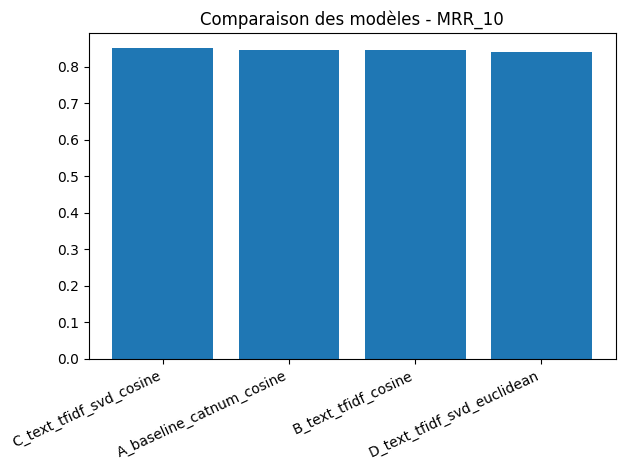

 Graphique sauvegardé : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\mrr_comparison.png


In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["run"], results_df["MRR_10"])
plt.title("Comparaison des modèles - MRR_10")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plot_path = OUT_DIR / "mrr_comparison.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(" Graphique sauvegardé :", plot_path)

### Log le graphique dans mlflow

In [24]:
with mlflow.start_run(run_name="SUMMARY_ARTIFACTS"):
    mlflow.log_artifact(str(results_csv), artifact_path="summary")
    mlflow.log_artifact(str(plot_path), artifact_path="summary")

### Preuve de traçabilité

In [25]:
exp = mlflow.get_experiment_by_name("CityTaste-Reco-Pipeline")
runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

cols_to_show = [
    "run_name",
    "status",
    "metrics.MRR_10",
    "metrics.HitRate_10",
    "metrics.fit_time_sec",
    "params.metric",
    "params.include_text",
    "params.use_svd",
    "params.n_neighbors"
]

available_cols = [c for c in cols_to_show if c in runs_df.columns]
display(runs_df[available_cols].sort_values("metrics.MRR_10", ascending=False))

,status,metrics.MRR_10,metrics.HitRate_10,metrics.fit_time_sec,params.metric,params.include_text,params.use_svd,params.n_neighbors
2,FINISHED,0.850005,0.891403,3.30,cosine,True,True,15
4,FINISHED,0.846122,0.886878,0.19,cosine,False,False,15
3,FINISHED,0.844646,0.895928,1.01,cosine,True,False,15
1,FINISHED,0.839749,0.900452,2.90,euclidean,True,True,15
0,FINISHED,NaN,NaN,NaN,None,None,None,None
5,FAILED,NaN,NaN,NaN,cosine,False,False,15
6,FAILED,NaN,NaN,NaN,None,None,None,None


### Mini conclusion

Nous avons comparé plusieurs variantes du système de recommandation.

La métrique principale utilisée est **MRR@10**, qui mesure la qualité du classement des recommandations (plus un bon résultat apparaît tôt, meilleur est le score).

Résultats observés :

- Le modèle **baseline (cat + num)** donne les performances les plus faibles.
- L’ajout du **texte avec TF-IDF** améliore nettement la qualité des recommandations.
- La meilleure performance est obtenue avec **TF-IDF + réduction SVD**, qui permet de réduire le bruit et d’obtenir une représentation plus compacte des lieux.

Le modèle retenu est donc **TF-IDF + SVD + cosine similarity**, car il offre le meilleur compromis entre :

- qualité du ranking (MRR@10 élevé)
- stabilité
- coût de calcul raisonnable.

Tous les runs, paramètres, métriques et artefacts ont été **traçés avec MLflow**, assurant la reproductibilité de l’expérience.

----


# La façon dont on a contrui les modèles

## Modèle A — Baseline : Catégories + variables numériques (cosine similarity)

Le premier modèle est un **modèle de base (baseline)**.  
Il utilise uniquement les informations structurées du dataset, comme :

- les catégories du lieu (type d’établissement, cuisine, ville, etc.)
- certaines variables numériques (latitude, longitude, distance au centre)

Les variables catégorielles sont transformées avec **One-Hot Encoding**, ce qui convertit chaque catégorie en colonnes numériques.

Ensuite, on utilise **k-Nearest Neighbors (kNN)** avec la **similarité cosinus** pour trouver les lieux les plus similaires.

Principe :
- chaque lieu est représenté par un vecteur de caractéristiques
- le modèle cherche les lieux les plus proches dans cet espace

Ce modèle est simple et sert de **référence de départ pour comparer les modèles plus avancés**.

## Modèle B — TF-IDF + kNN (cosine similarity)

Dans ce deuxième modèle, nous ajoutons **l'information textuelle** des lieux.

Le texte (nom du lieu, description ou autres informations textuelles) est transformé en vecteurs numériques avec **TF-IDF (Term Frequency – Inverse Document Frequency)**.

TF-IDF mesure l’importance d’un mot dans un document par rapport à tous les documents.

Cela permet de représenter chaque lieu par :
- les mots qui apparaissent dans sa description
- leur importance relative

Une fois les vecteurs TF-IDF créés, on utilise encore **kNN avec la similarité cosinus** pour trouver les lieux similaires.

Avantage :
- le modèle comprend mieux les similitudes entre lieux grâce au texte.

## Modèle C — TF-IDF + réduction SVD + kNN (cosine similarity)

Ce modèle améliore le modèle précédent en ajoutant une étape appelée **réduction de dimension (SVD : Singular Value Decomposition)**.

Après la création des vecteurs TF-IDF, on applique **Truncated SVD** pour :

- réduire le nombre de dimensions
- enlever du bruit dans les données
- capturer les relations sémantiques entre les mots

Cela permet d’obtenir une représentation plus compacte et souvent plus pertinente du texte.

Ensuite, comme dans les modèles précédents, on utilise **kNN avec la similarité cosinus** pour trouver les lieux similaires.

Ce modèle est généralement **plus stable et plus efficace que TF-IDF seul**.

## Modèle D — TF-IDF + SVD + kNN (distance euclidienne)

Ce dernier modèle utilise la même représentation que le modèle précédent :

- texte transformé avec TF-IDF
- réduction de dimension avec SVD

La différence est dans la **mesure de distance utilisée pour comparer les lieux**.

Au lieu de la similarité cosinus, on utilise la **distance euclidienne**.

La distance euclidienne mesure la distance directe entre deux points dans l’espace vectoriel.

Cela permet de tester si une autre mesure de distance peut améliorer la qualité des recommandations.

Ce modèle est donc une **variante du modèle C**, utilisée pour comparer l’impact du choix de la métrique de distance.

In [1]:
### Fin du notebook de prétraitement et évaluation basique
### Ajout de quelques colonnes pour les notes

In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path("data/processed/ottawa_places_cleaned_v2.csv")
df = pd.read_csv(csv_path)

# Ajouter les colonnes si elles n'existent pas
if "google_rating" not in df.columns:
    df["google_rating"] = pd.NA

if "google_user_rating_count" not in df.columns:
    df["google_user_rating_count"] = pd.NA

if "rating_source" not in df.columns:
    df["rating_source"] = pd.NA

# Sauvegarder
df.to_csv(csv_path, index=False)

print("Colonnes ajoutées ")
print(df.columns.tolist())
display(df.head())

Colonnes ajoutées 
['osm_type', 'osm_id', 'name', 'place_type', 'amenity', 'tourism', 'cuisine', 'lat', 'lon', 'addr_housenumber', 'addr_street', 'addr_city', 'addr_postcode', 'address', 'phone', 'website', 'opening_hours', 'wheelchair', 'brand', 'source', 'tags_json', 'address_clean', 'dist_to_center_km', 'text', 'eval_label', 'google_rating', 'google_user_rating_count', 'rating_source']


,osm_type,osm_id,name,place_type,amenity,tourism,cuisine,lat,lon,addr_housenumber,...,brand,source,tags_json,address_clean,dist_to_center_km,text,eval_label,google_rating,google_user_rating_count,rating_source
0,relation,14526702,Les Suites Hotel,hotel,Unknown,hotel,Unknown,45.426134,-75.688731,130,...,Unknown,City of Ottawa,"{""@id"": ""relation/14526702"", ""addr:city"": ""Ott...","130 Besserer Street, Ottawa K1N 9M9",0.838080,Les Suites Hotel hotel Unknown 130 Besserer St...,hotel,<NA>,<NA>,<NA>
1,way,31813259,Embassy Hotel and Suites,hotel,Unknown,hotel,Unknown,45.419679,-75.688818,25,...,Unknown,NaN,"{""@id"": ""way/31813259"", ""addr:housenumber"": ""2...","25 Cartier Street, Ottawa K2P 1J2",0.684773,Embassy Hotel and Suites hotel Unknown 25 Cart...,hotel,<NA>,<NA>,<NA>
2,way,31813278,The Business Inn & Suites,hotel,Unknown,hotel,Unknown,45.416980,-75.689237,180,...,Unknown,City of Ottawa,"{""@id"": ""way/31813278"", ""addr:housenumber"": ""1...","180 MacLaren Street, Ottawa Unknown",0.799298,The Business Inn & Suites hotel Unknown 180 Ma...,hotel,<NA>,<NA>,<NA>
3,way,46016942,Ottawa Jail Hostel,hostel,Unknown,hostel,Unknown,45.425111,-75.688451,75,...,Unknown,NaN,"{""@id"": ""way/46016942"", ""addr:housenumber"": ""7...","75 Nicholas Street, Ottawa K1N 7B9",0.792124,Ottawa Jail Hostel hostel Unknown 75 Nicholas ...,hostel,<NA>,<NA>,<NA>
4,way,55411730,Sonder Rideau Apartments Downtown,hotel,Unknown,hotel,Unknown,45.420741,-75.694605,161,...,Unknown,NaN,"{""@id"": ""way/55411730"", ""addr:housename"": ""Res...","161 Laurier Avenue West, Ottawa K1P 5J2",0.219363,Sonder Rideau Apartments Downtown hotel Unknow...,hotel,<NA>,<NA>,<NA>


In [19]:
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("GOOGLE_MAPS_API_KEY")

In [7]:
import os
import requests
import pandas as pd

API_KEY = os.getenv("GOOGLE_MAPS_API_KEY")
print("Clé chargée :", API_KEY[:10] + "..." if API_KEY else "Aucune")

url = "https://places.googleapis.com/v1/places:searchText"
headers = {
    "Content-Type": "application/json",
    "X-Goog-Api-Key": API_KEY,
    "X-Goog-FieldMask": "places.id,places.displayName,places.formattedAddress,places.rating,places.userRatingCount"
}
payload = {
    "textQuery": "Lord Elgin Ottawa",
    "languageCode": "fr",
    "regionCode": "CA",
    "maxResultCount": 3
}

r = requests.post(url, headers=headers, json=payload, timeout=30)

print("Status code :", r.status_code)
print(r.text[:1500])

Clé chargée : AIzaSyC4MI...
Status code : 200
{
  "places": [
    {
      "id": "ChIJART0faoFzkwRJyLS0gjq6Wg",
      "formattedAddress": "100 Elgin St, Ottawa, ON K1P 5K8",
      "rating": 4.3,
      "userRatingCount": 3430,
      "displayName": {
        "text": "Lord Elgin Hotel",
        "languageCode": "fr"
      }
    }
  ]
}



In [9]:
# Colonnes numériques
for col in ["google_rating", "google_user_rating_count", "google_match_score"]:
    if col not in df.columns:
        df[col] = pd.NA
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Colonnes texte
for col in ["rating_source", "google_place_id"]:
    if col not in df.columns:
        df[col] = pd.NA
    df[col] = df[col].astype("string")

In [11]:
import os
import math
import time
import difflib
import requests
import pandas as pd
from pathlib import Path
from tqdm import tqdm

API_KEY = os.getenv("GOOGLE_MAPS_API_KEY")
if not API_KEY:
    raise ValueError("Clé API absente. Définis GOOGLE_MAPS_API_KEY avant de lancer ce script.")

csv_path = Path("data/processed/ottawa_places_cleaned_v2.csv")
df = pd.read_csv(csv_path)

# Initialisation propre des colonnes
for col in ["google_rating", "google_user_rating_count", "google_match_score"]:
    if col not in df.columns:
        df[col] = pd.NA
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["rating_source", "google_place_id"]:
    if col not in df.columns:
        df[col] = pd.NA
    df[col] = df[col].astype("string")

TEXT_SEARCH_URL = "https://places.googleapis.com/v1/places:searchText"
HEADERS = {
    "Content-Type": "application/json",
    "X-Goog-Api-Key": API_KEY,
    "X-Goog-FieldMask": ",".join([
        "places.id",
        "places.displayName",
        "places.formattedAddress",
        "places.location",
        "places.rating",
        "places.userRatingCount",
    ])
}

def safe_text(x):
    if pd.isna(x):
        return ""
    v = str(x).strip()
    if v.lower() in {"nan", "none", "null", "undefined"}:
        return ""
    return v

def haversine_km(lat1, lon1, lat2, lon2):
    if any(pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return None
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

def similarity(a, b):
    a = safe_text(a).lower()
    b = safe_text(b).lower()
    if not a or not b:
        return 0.0
    return difflib.SequenceMatcher(None, a, b).ratio()

def build_query(row):
    name = safe_text(row.get("name"))
    address = safe_text(row.get("address_clean")) or safe_text(row.get("address"))
    city = safe_text(row.get("addr_city")) or "Ottawa"
    return ", ".join([x for x in [name, address, city, "ON", "Canada"] if x])

def google_text_search(query, max_results=5):
    payload = {
        "textQuery": query,
        "languageCode": "fr",
        "regionCode": "CA",
        "maxResultCount": max_results,
    }
    r = requests.post(TEXT_SEARCH_URL, headers=HEADERS, json=payload, timeout=30)
    r.raise_for_status()
    return r.json().get("places", [])

def pick_best_match(row, places):
    row_name = safe_text(row.get("name"))
    row_addr = safe_text(row.get("address_clean")) or safe_text(row.get("address"))
    row_lat = pd.to_numeric(row.get("lat"), errors="coerce")
    row_lon = pd.to_numeric(row.get("lon"), errors="coerce")

    best = None
    best_score = -1

    for p in places:
        p_name = safe_text((p.get("displayName") or {}).get("text"))
        p_addr = safe_text(p.get("formattedAddress"))
        p_loc = p.get("location") or {}
        p_lat = p_loc.get("latitude")
        p_lon = p_loc.get("longitude")

        name_score = similarity(row_name, p_name)
        addr_score = similarity(row_addr, p_addr)

        dist_score = 0.0
        dist_km = haversine_km(row_lat, row_lon, p_lat, p_lon)
        if dist_km is not None:
            if dist_km <= 0.2:
                dist_score = 1.0
            elif dist_km <= 1.0:
                dist_score = 0.8
            elif dist_km <= 3.0:
                dist_score = 0.5
            else:
                dist_score = 0.1

        score = 0.6 * name_score + 0.25 * addr_score + 0.15 * dist_score

        if score > best_score:
            best_score = score
            best = {
                "place_id": p.get("id"),
                "display_name": p_name,
                "formatted_address": p_addr,
                "rating": p.get("rating"),
                "user_rating_count": p.get("userRatingCount"),
                "match_score": round(score, 4),
                "distance_km": None if dist_km is None else round(dist_km, 3),
            }

    return best

# Mode complet
TEST_MODE = False
TEST_N = 10

work_df = df.copy()
if TEST_MODE:
    work_df = work_df.head(TEST_N).copy()

for idx, row in tqdm(work_df.iterrows(), total=len(work_df)):
    # saute si déjà enrichi
    if pd.notna(df.at[idx, "google_rating"]) and pd.notna(df.at[idx, "google_user_rating_count"]):
        continue

    query = build_query(row)

    try:
        places = google_text_search(query, max_results=5)
        if not places:
            continue

        best = pick_best_match(row, places)
        if not best:
            continue

        # seuil de confiance
        if best["match_score"] >= 0.72:
            df.at[idx, "google_place_id"] = best["place_id"]
            df.at[idx, "google_rating"] = best["rating"]
            df.at[idx, "google_user_rating_count"] = best["user_rating_count"]
            df.at[idx, "rating_source"] = "google_places_api"
            df.at[idx, "google_match_score"] = best["match_score"]

        time.sleep(0.15)  # petite pause pour rester raisonnable

    except Exception as e:
        print(f"[WARN] ligne {idx} | {row.get('name')} | {e}")

  4%|▍         | 48/1104 [01:23<1:12:58,  4.15s/it]

[WARN] ligne 47 | The Hollander Gastropub | HTTPSConnectionPool(host='places.googleapis.com', port=443): Max retries exceeded with url: /v1/places:searchText (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1006)')))


100%|██████████| 1104/1104 [38:01<00:00,  2.07s/it] 


In [12]:
# Sauvegarde dans un nouveau fichier
out_path = Path("data/processed/ottawa_places_enriched_google.csv")
df.to_csv(out_path, index=False)

print(f"Fichier enrichi sauvegardé : {out_path}")

Fichier enrichi sauvegardé : data\processed\ottawa_places_enriched_google.csv


In [13]:
filled = df["google_rating"].notna().sum()
total = len(df)

print(f"Lignes enrichies avec une vraie note : {filled}/{total}")
print(f"Pourcentage : {filled/total:.2%}")

display(
    df.loc[df["google_rating"].notna(), 
           ["name", "google_rating", "google_user_rating_count", "rating_source", "google_match_score"]]
      .head(20)
)

Lignes enrichies avec une vraie note : 736/1104
Pourcentage : 66.67%


,name,google_rating,google_user_rating_count,rating_source,google_match_score
0,Les Suites Hotel,4.0,2249.0,google_places_api,0.8637
1,Embassy Hotel and Suites,4.0,1277.0,google_places_api,0.8933
2,The Business Inn & Suites,4.4,2778.0,google_places_api,0.9429
3,Ottawa Jail Hostel,4.3,2395.0,google_places_api,0.8394
5,Hampton Inn by Hilton Ottawa,4.4,2321.0,google_places_api,0.9779
11,Fairmont Château Laurier,4.4,6870.0,google_places_api,0.7970
13,Red Lobster,4.3,3504.0,google_places_api,0.9429
14,Kanata Noodle House,4.4,1189.0,google_places_api,0.8679
15,Comfort Inn Ottawa West - Kanata,3.7,924.0,google_places_api,0.7531
16,Days Inn Ottawa West,3.6,1272.0,google_places_api,0.8024
